In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.diffusion import DDIMProcess
from src.misc import load_config
from src.predict import load_predictor


def predict_noise(model, images, steps, condition, guidance):
    if condition is None:
        return model(images, steps)
    if guidance == 1.0:
        return model(images, steps, condition)

    null = model(images, steps, torch.zeros_like(condition))
    guided = model(images, steps, condition)
    return null + guidance * (guided - null)


In [2]:
PREDICT_CONFIG = ROOT / "config" / "predict.yaml"
SAMPLE_COUNT = 4
DDIM_STEPS = 20
SEED = 0

In [3]:
torch.manual_seed(SEED)

config = load_config(PREDICT_CONFIG)
run_dir = Path(config["run_dir"])
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
predictor = load_predictor(run_dir, device=device)

model = predictor.sampler.model
ddpm = predictor.sampler.ddpm
ddim = DDIMProcess(ddpm, min(DDIM_STEPS, ddpm.num_timesteps))
images = torch.randn(
    SAMPLE_COUNT,
    predictor.num_phases,
    predictor.image_size,
    predictor.image_size,
    device=device,
)
fractions = config.get("phase_fractions")
condition = (
    None
    if fractions is None
    else torch.tensor(fractions, device=device).expand(SAMPLE_COUNT, -1)
)

with torch.no_grad():
    for step, prev_step in ddim.schedule:
        steps = torch.full((SAMPLE_COUNT,), step, dtype=torch.long, device=device)
        noise = predict_noise(
            model,
            images,
            steps,
            condition,
            config["guidance_scale"],
        )
        images = ddim.step(images, noise, step=step, prev_step=prev_step)

labels = images.argmax(dim=1).cpu()
counts = torch.bincount(labels.flatten(), minlength=predictor.num_phases)
sample_fractions = [round(value, 4) for value in (counts / counts.sum()).tolist()]
print(
    f"run={run_dir.name} steps={len(ddim.schedule)} "
    f"fractions={sample_fractions}"
)

run=20260715-185426-491588 steps=20 fractions=[0.5372, 0.1754, 0.2874]


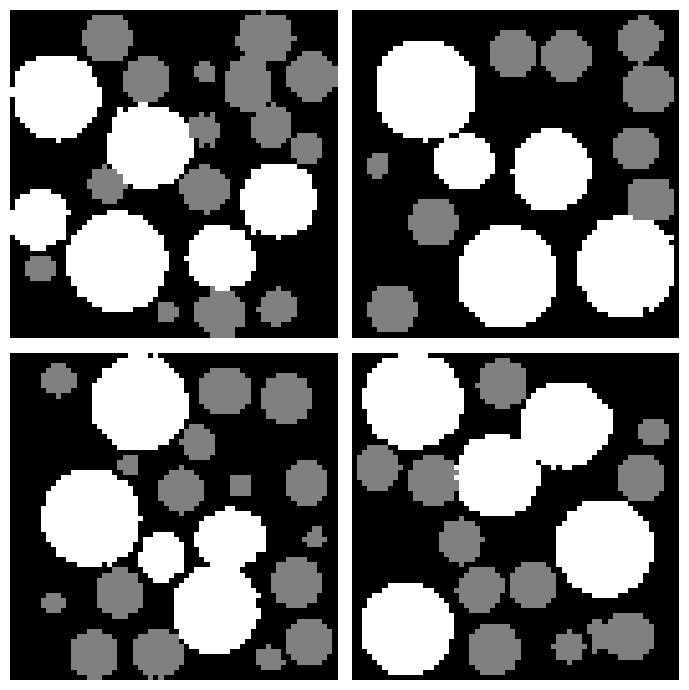

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7), squeeze=False)
for axis, image in zip(axes.ravel(), labels):
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=predictor.num_phases - 1,
        interpolation="nearest",
    )
    axis.axis("off")
plt.tight_layout()